In [144]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv('data/loan.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={'home_onwership' : 'home_ownership'}, inplace=True)
objects = df.select_dtypes(include='object').columns
df[objects] = df[objects].apply(lambda X: X.str.lower())
df['previous_loan'] = df['previous_loan'].map({'no':0, 'yes':1})
df.head()

,age,gender,education,person_income,employee_experience,home_ownership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_status
0,22,female,master,71948,0,rent,35000,personal,16.02,0.49,3,561,0,1
1,21,female,high school,12282,0,own,1000,education,11.14,0.08,2,504,1,0
2,25,female,high school,12438,3,mortgage,5500,medical,12.87,0.44,3,635,0,1
3,23,female,bachelor,79753,0,rent,35000,medical,15.23,0.44,2,675,0,1
4,24,male,master,66135,1,rent,35000,medical,14.27,0.53,4,586,0,1


In [51]:
features = ['education','person_income', 'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'previous_loan']
target = ['loan_status']
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.3, random_state=0)
X_train.head()

,education,person_income,home_ownership,loan_amount,loan_intent,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan
21652,associate,51613,rent,6000,venture,11.78,0.12,10,614,0
31615,associate,137767,mortgage,19200,personal,11.36,0.14,15,669,1
34712,bachelor,52574,rent,6150,medical,9.07,0.12,12,688,0
5455,master,55083,mortgage,5000,education,7.14,0.09,4,694,0
36900,associate,112215,mortgage,6000,personal,11.00,0.05,4,674,0


In [127]:
X_train.select_dtypes(include=['int', 'float']).columns

Index(['person_income', 'loan_amount', 'loan_interest_rate', 'loan_percentage',
       'credit_history', 'credit_score', 'previous_loan'],
      dtype='object')

In [129]:
for col in X_train.select_dtypes(include=['int', 'float']).columns:
    print(f"Skew of {col} : {df[col].skew(): .2f}")

Skew of person_income :  34.14
Skew of loan_amount :  1.18
Skew of loan_interest_rate :  0.21
Skew of loan_percentage :  1.03
Skew of credit_history :  1.63
Skew of credit_score : -0.61
Skew of previous_loan : -0.03


In [58]:
X_train['education'].unique()

array(['associate', 'bachelor', 'master', 'high school', 'doctorate'],
      dtype=object)

In [86]:
encoding_transformer = ColumnTransformer(transformers=[
    ('education', OrdinalEncoder(categories=[['high school', 'associate', 'bachelor', 'master', 'doctorate']], dtype=np.int64), [0]),
    ('home_ownership_loan_intent', OneHotEncoder(drop='first', dtype=np.int64, sparse_output=False, handle_unknown='ignore'), [2,4])
], verbose_feature_names_out=False, remainder='passthrough')

In [ ]:
temp = pd.DataFrame(encoding_transformer.fit_transform(X_train),
                    columns=encoding_transformer.get_feature_names_out())
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31500 entries, 0 to 31499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   education                    31500 non-null  float64
 1   home_ownership_other         31500 non-null  float64
 2   home_ownership_own           31500 non-null  float64
 3   home_ownership_rent          31500 non-null  float64
 4   loan_intent_education        31500 non-null  float64
 5   loan_intent_homeimprovement  31500 non-null  float64
 6   loan_intent_medical          31500 non-null  float64
 7   loan_intent_personal         31500 non-null  float64
 8   loan_intent_venture          31500 non-null  float64
 9   person_income                31500 non-null  float64
 10  loan_amount                  31500 non-null  float64
 11  loan_interest_rate           31500 non-null  float64
 12  loan_percentage              31500 non-null  float64
 13  credit_history  

In [91]:
func_transformer = ColumnTransformer(transformers=[
    ('right_skewed', FunctionTransformer(func = np.log1p), [9,10]),
    ('left_skewed', FunctionTransformer(func=np.square), [14])
], remainder='passthrough')

In [88]:
scaler_transformer = ColumnTransformer(transformers = [
    ('scaling', StandardScaler(), [9,10,14])
], remainder='passthrough', verbose_feature_names_out=False)

In [96]:
pipe = Pipeline([
    ('encoding', encoding_transformer),
    ('function_transformer', func_transformer),
    ('scaler', scaler_transformer),
    ('model', LogisticRegression(max_iter=10000, random_state=0))
]) 

In [98]:
pipe.fit(X_train, y_train.values.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoding', ...), ('function_transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('education', ...), ('home_ownership_loan_intent', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, defau

In [99]:
y_pred = pipe.predict(X_test)

In [ ]:
cross_val_score(pipe, df[features], df[target].values.ravel(), cv = 5)

array([0.88133333, 0.90155556, 0.87822222, 0.89688889, 0.90477778])

<Axes: xlabel='credit_score', ylabel='Count'>

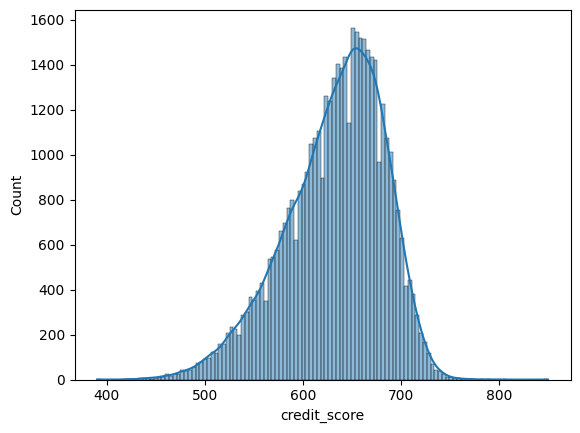

In [83]:
sns.histplot(df['credit_score'], kde = True)

In [111]:
education_pipe = Pipeline([
    ('OE', OrdinalEncoder(categories=[['high school', 'associate', 'bachelor', 'master', 'doctorate']], dtype=np.int32))
])

categorial_pipe = Pipeline([
    ('OHE', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore', dtype=np.int32) )
])

right_skewed_pipe = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

left_skewed_pipe = Pipeline([
    ('square', FunctionTransformer(func = np.square, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

scaler_pipe = Pipeline([
    ('scaler', StandardScaler())
])

In [139]:
preprocessor = ColumnTransformer(transformers=[
    ('education', education_pipe, ['education']),
    ('categorial', categorial_pipe, ['home_ownership', 'loan_intent']),
    ('right_skew', right_skewed_pipe, ['person_income', 'loan_amount', 'credit_history', 'loan_percentage']),
    ('left_skew', left_skewed_pipe, ['credit_score']),
    ('scaling', scaler_pipe, ['loan_interest_rate', 'previous_loan'])
], verbose_feature_names_out=False, remainder='drop')

In [140]:
X_train_trfd = pd.DataFrame(preprocessor.fit_transform(X_train),
                            index=X_train.index,
                            columns= preprocessor.get_feature_names_out())
X_train_trfd.columns

Index(['education', 'home_ownership_other', 'home_ownership_own',
       'home_ownership_rent', 'loan_intent_education',
       'loan_intent_homeimprovement', 'loan_intent_medical',
       'loan_intent_personal', 'loan_intent_venture', 'person_income',
       'loan_amount', 'credit_history', 'loan_percentage', 'credit_score',
       'loan_interest_rate', 'previous_loan'],
      dtype='object')

In [141]:
for col in X_train_trfd.columns:
    print(f"Skew of {col} : {X_train_trfd[col].skew(): .2f}")

Skew of education :  0.19
Skew of home_ownership_other :  20.15
Skew of home_ownership_own :  3.54
Skew of home_ownership_rent : -0.09
Skew of loan_intent_education :  1.48
Skew of loan_intent_homeimprovement :  2.54
Skew of loan_intent_medical :  1.58
Skew of loan_intent_personal :  1.77
Skew of loan_intent_venture :  1.72
Skew of person_income :  0.23
Skew of loan_amount : -0.44
Skew of credit_history :  0.44
Skew of loan_percentage :  0.83
Skew of credit_score : -0.39
Skew of loan_interest_rate :  0.22
Skew of previous_loan : -0.03


In [142]:
pipe2 = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000))
])

In [143]:
pipe2.fit(X_train, y_train)
pred = pipe2.predict(X_test)

X = df[features]
y = df[target]

print(f"Accuracy : {np.mean(cross_val_score(pipe2, X, y.values.ravel(),  cv=5)): .4f}")

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy :  0.8979


In [146]:
heavy_skewness = Pipeline(steps = [
    ('power_trf', PowerTransformer(method='box-cox'))
])

In [149]:
person_income_trfd = pd.DataFrame(heavy_skewness.fit_transform(X_train[['person_income']]))
person_income_trfd.skew()

0   -0.019136
dtype: float64

In [ ]:
yeo_johnson_trf = PowerTransformer(method='yeo-johnson')

person_income_trfd = pd.DataFrame(heavy_skewness.fit_transform(X_train[['person_income']]))
person_income_trfd.skew()

---

# Power Transformer 
Power Transformers are used to Normalize heavily skewed data.
since person_income has no negative and zero's both works the same.

# Box - Cox

box-cox only accepts positive numbers no zero's and negative's are allowed.

# Yeo - Johnson

yeo-johnson accepts all numbers.
Power Transformer has builtin Standardization so no need to do it again 

---